# Mini-PVA Totalp – Bifacial Yield & Performance Map (Final)

**Site:** Totalp, Davos (N46.838°, E9.813°, 2480 m a.s.l.) | **Period:** October 2024 – March 2025  
**Group 1 focus:** Very steep ground inclinations (HN ≥ 20°)

This notebook builds on the multi-day analysis to produce the final project deliverables:
bifacial yield calculation, performance maps, and a regression model for unmeasured configurations.

Sections 1–10 are identical to the Week 2/3 notebook (data loading, cleaning, interpolation,
solar position, GHI variability, yield calculation). The new content starts at Section 11.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import matplotlib.dates as mdates
import pvlib

### 1. Site Constants

In [2]:
LAT, LON, ALT = 46.838, 9.813, 2480   # latitude [°N], longitude [°E], altitude [m]
TZ = "Europe/Zurich"

RELEVANT_CHANNELS = {
    18: "Front row – Front side",
    22: "Front row – Back side",
     3: "Back row – Front side",
     7: "Back row – Back side",
}
COLORS = {18: "tab:blue", 22: "tab:cyan", 3: "tab:red", 7: "tab:orange"}

### 2. Data Loading

In [3]:
stc_powers = pd.read_csv('../data/raw/STC_Powers.csv', sep=';', decimal=',')

files = sorted(glob.glob('../data/raw/mini_pva_daily/*.csv'))
print(f"Mini-PVA daily files found: {len(files)}")
minipva = pd.concat(
    [pd.read_csv(f, sep=';', decimal=',') for f in files],
    ignore_index=True
)

env_data_full = pd.read_csv('../data/raw/environmental_data.csv', sep=';', decimal=',')
largeinstallation_full = pd.read_csv(
    '../data/raw/largeInstallation_measurementData.csv', sep=';', decimal=','
)

print(minipva.info())
print(env_data_full.info())
print(largeinstallation_full.info())

Mini-PVA daily files found: 180


C:\Users\chaen\AppData\Local\Temp\ipykernel_13300\2210977093.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  minipva = pd.concat(


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 951999 entries, 0 to 951998
Data columns (total 15 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID.Results  951999 non-null  float64
 1   mes_date    951999 non-null  object 
 2   ID.Modul    951999 non-null  object 
 3   channel     951999 non-null  object 
 4   U0          951999 non-null  float64
 5   Ik          951999 non-null  float64
 6   Pmpp        951999 non-null  float64
 7   FF          927520 non-null  float64
 8   Ghor        951999 non-null  object 
 9   Tluft       951999 non-null  object 
 10  RA          951999 non-null  object 
 11  MN          951999 non-null  object 
 12  HN          951999 non-null  object 
 13  Res         951999 non-null  object 
 14  mes_time    951999 non-null  object 
dtypes: float64(5), object(10)
memory usage: 108.9+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1546561 entries, 0 to 1546560
Data columns (total 5 columns):
 # 

### 3. Mini-PVA Data Cleaning

Data cleaning challenges encountered:

| Problem | Cause | Solution |
|---------|-------|----------|
| MN values > 1000 (e.g. 65516 → should be −20°) | Unsigned 16-bit integer overflow | Subtract 65536 |
| 8 rows with ambiguous timestamp | DST transition 27.10.2024 02:00→03:00 | `ambiguous='NaT'` → drop |
| MN = 0 (7936 rows) | Night/safe position of actuator | Drop (Pmpp ≈ 0) |
| Overnight interpolation gaps | Standard time-interp bridges midnight | Day-wise interpolation |
| Large files in Git | CSV files > 100 MB | `.gitignore` for `data/` |

In [4]:
# mes_date already contains full datetime — mes_time is redundant
minipva.drop(columns=['mes_time'], inplace=True)

minipva['mes_date'] = pd.to_datetime(
    minipva['mes_date'],
    format='%m/%d/%Y %I:%M:%S %p',
    errors='coerce'
)

minipva['channel'] = pd.to_numeric(minipva['channel'], errors='coerce').astype('Int64')
minipva['RA']      = pd.to_numeric(minipva['RA'],      errors='coerce')
minipva['MN']      = pd.to_numeric(minipva['MN'],      errors='coerce')
minipva['HN']      = pd.to_numeric(minipva['HN'],      errors='coerce')

# Tluft: "15.1°C" → float
minipva['Tluft'] = (
    minipva['Tluft'].astype(str)
    .str.replace('°C', '', regex=False)
    .str.strip()
    .astype(float)
)

# Ghor: may use comma as decimal separator
minipva['Ghor'] = pd.to_numeric(
    minipva['Ghor'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)

n_failed = minipva['mes_date'].isna().sum()
if n_failed > 0:
    print(f"⚠  {n_failed} timestamps could not be parsed")

# Must sort BEFORE localising to avoid AmbiguousTimeError
minipva.sort_values('mes_date', inplace=True)
minipva.reset_index(drop=True, inplace=True)

minipva['mes_date'] = minipva['mes_date'].dt.tz_localize(
    'Europe/Zurich', ambiguous='NaT', nonexistent='shift_forward'
)
n_ambiguous = minipva['mes_date'].isna().sum()
print(f"Ambiguous timestamps (DST transition): {n_ambiguous} rows → dropped")
minipva.dropna(subset=['mes_date'], inplace=True)

minipva.sort_values(['channel', 'mes_date'], inplace=True)
minipva.reset_index(drop=True, inplace=True)

# MN: unsigned 16-bit integer overflow (e.g. 65516 = −20° in signed int16)
overflow_mask = minipva['MN'] > 1000
minipva.loc[overflow_mask, 'MN'] = minipva.loc[overflow_mask, 'MN'] - 65536
print(f"MN overflow corrections: {overflow_mask.sum()} rows")

# Negative MN = homing/night position → drop
invalid_mn = minipva['MN'] < 0
print(f"Negative MN (homing/night): {invalid_mn.sum()} rows → dropped")
minipva = minipva[~invalid_mn].copy()

# RA: hardware limits 115–719 mm
invalid_ra = (minipva['RA'] < 115) | (minipva['RA'] > 719)
print(f"Invalid RA (outside 115–719 mm): {invalid_ra.sum()} rows → dropped")
minipva = minipva[~invalid_ra].copy()

# MN = 0: safe/night position (Pmpp ≈ 0) → drop
invalid_mn0 = minipva['MN'] == 0
print(f"MN = 0 (safe/night position): {invalid_mn0.sum()} rows → dropped")
minipva = minipva[~invalid_mn0].copy()

minipva.reset_index(drop=True, inplace=True)

print(f"\nAfter cleaning: {len(minipva):,} rows")
print(f"  MN values: {sorted(minipva['MN'].dropna().unique())}")
print(f"  RA values: {sorted(minipva['RA'].dropna().unique())}")
print(f"  HN values: {sorted(minipva['HN'].dropna().unique())}")

# STC normalisation: Pnominal = Pmpp / P_STC
stc_powers['Channel'] = stc_powers['Channel'].astype(int)
if 'STC_Power_mW' not in minipva.columns:
    minipva = minipva.merge(stc_powers, left_on='channel', right_on='Channel', how='left')
    minipva.drop(columns=['Channel'], inplace=True)

minipva['Pnominal'] = minipva['Pmpp'] / minipva['STC_Power_mW']
print(f"\nSTC normalisation: {minipva['Pnominal'].isna().sum()} rows without STC value")

Ambiguous timestamps (DST transition): 8 rows → dropped
MN overflow corrections: 7 rows
Negative MN (homing/night): 7 rows → dropped
Invalid RA (outside 115–719 mm): 0 rows → dropped
MN = 0 (safe/night position): 7936 rows → dropped

After cleaning: 944,048 rows
  MN values: [10, 20, 30, 40, 45, 50, 60, 70, 80, 90]
  RA values: [115, 137, 166, 205, 263, 358, 544, 670, 688, 700]
  HN values: [0, 10, 20, 30, 40]

STC normalisation: 0 rows without STC value


### 4. Environmental & Large Installation Cleaning

In [5]:
env_data_full.dropna(subset=['Timestamp'], inplace=True)
env_data_full['Timestamp'] = pd.to_datetime(env_data_full['Timestamp'], format='mixed')
env_data_full.sort_values('Timestamp', inplace=True)
env_data_full['Timestamp'] = env_data_full['Timestamp'].dt.tz_localize(
    'Europe/Zurich', ambiguous='NaT', nonexistent='shift_forward'
)
env_data_full.dropna(subset=['Timestamp'], inplace=True)
env_data_full.reset_index(drop=True, inplace=True)

print(f"Environmental data: {len(env_data_full):,} rows | "
      f"{env_data_full['Timestamp'].min()} → {env_data_full['Timestamp'].max()}")

largeinstallation_full['Timestamp'] = pd.to_datetime(
    largeinstallation_full['Timestamp'], format='mixed'
)
largeinstallation_full.sort_values('Timestamp', inplace=True)
largeinstallation_full['Timestamp'] = largeinstallation_full['Timestamp'].dt.tz_localize(
    'Europe/Zurich', ambiguous='NaT', nonexistent='shift_forward'
)
largeinstallation_full.dropna(subset=['Timestamp'], inplace=True)
largeinstallation_full.columns = [c.replace(' ', '_') for c in largeinstallation_full.columns]
largeinstallation_full.reset_index(drop=True, inplace=True)

print(f"Large installation: {len(largeinstallation_full):,} rows | "
      f"{largeinstallation_full['Timestamp'].min()} → "
      f"{largeinstallation_full['Timestamp'].max()}")

Environmental data: 1,545,841 rows | 2024-10-01 00:00:00+02:00 → 2025-03-31 00:00:00+02:00
Large installation: 1,545,481 rows | 2024-10-01 00:00:00+02:00 → 2025-03-31 00:00:00+02:00


### 5. Day-wise Interpolation

Standard time-based interpolation would bridge overnight gaps with physically meaningless
values (e.g. interpolating GHI from 23:00 to 07:00). The function below restricts
interpolation to within each calendar day only.

In [6]:
def interpolate_by_day(source_df, source_ts_col, target_timestamps):
    """
    Interpolate source_df onto target_timestamps using time-based linear
    interpolation, restricted to within each calendar day.
    """
    data_cols = [c for c in source_df.columns if c != source_ts_col]
    result = pd.DataFrame(index=target_timestamps, columns=data_cols, dtype=float)
    result.index.name = source_ts_col

    target_dates = pd.Series(target_timestamps).dt.date.unique()

    for date in target_dates:
        day_targets = target_timestamps[
            pd.Series(target_timestamps).dt.date.values == date
        ]
        day_source = source_df[source_df[source_ts_col].dt.date == date].copy()

        if len(day_source) == 0 or len(day_targets) == 0:
            continue

        day_source = day_source.set_index(source_ts_col)
        day_source = day_source.groupby(level=0).mean()  # duplicate timestamps → mean

        combined_index = day_source.index.union(day_targets).sort_values()
        reindexed    = day_source.reindex(combined_index)
        interpolated = reindexed.interpolate(method='time')
        result.loc[day_targets, data_cols] = (
            interpolated.loc[day_targets, data_cols].values
        )

    for col in result.columns:
        try:
            result[col] = pd.to_numeric(result[col])
        except (ValueError, TypeError):
            pass
    return result


target_ts = pd.DatetimeIndex(sorted(minipva['mes_date'].unique()))

env_interp = interpolate_by_day(env_data_full.copy(), 'Timestamp', target_ts)

largeinstallation_full_copy = largeinstallation_full.copy()
largeinstallation_full_copy.columns = [
    'Timestamp' if c == 'Timestamp' else c
    for c in largeinstallation_full_copy.columns
]
large_interp = interpolate_by_day(largeinstallation_full_copy, 'Timestamp', target_ts)

print(f"Interpolation complete:")
print(f"  Env:   {env_interp.notna().any(axis=1).sum()} of {len(target_ts)} timestamps")
print(f"  Large: {large_interp.notna().any(axis=1).sum()} of {len(target_ts)} timestamps")

combined = minipva.copy()
combined = combined.merge(env_interp,   left_on='mes_date', right_index=True, how='left')
combined = combined.merge(large_interp, left_on='mes_date', right_index=True, how='left')
combined['env_missing'] = combined['GHI'].isna()

print(f"\nCombined shape: {combined.shape}")
print(f"Missing environmental data: {combined['env_missing'].sum():,} rows "
      f"({combined['env_missing'].mean()*100:.1f}%)")

Interpolation complete:
  Env:   936657 of 944048 timestamps
  Large: 936657 of 944048 timestamps

Combined shape: (944048, 34)
Missing environmental data: 7,391 rows (0.8%)


### 6. Solar Position (pvlib)

Solar position is calculated analytically from site coordinates and time.
`sun_up = True` (elevation > 0°) is used as a filter for yield integration.

In [7]:
location = pvlib.location.Location(
    latitude=LAT, longitude=LON, altitude=ALT, tz=TZ
)

solpos = location.get_solarposition(target_ts)
solpos_df = solpos[['zenith', 'azimuth', 'elevation']].rename(columns={
    'zenith':    'solar_zenith',
    'azimuth':   'solar_azimuth',
    'elevation': 'solar_elevation',
})
solpos_df['sun_up'] = solpos_df['solar_elevation'] > 0

combined = combined.merge(solpos_df, left_on='mes_date', right_index=True, how='left')

print(f"Measurements with sun above horizon: {combined['sun_up'].sum():,} "
      f"({combined['sun_up'].mean()*100:.1f}%)")

Measurements with sun above horizon: 836,400 (88.6%)


### 7. GHI Variability Index

A 2-minute rolling standard deviation of GHI serves as a proxy for cloud variability.
High values indicate rapidly changing cloud cover; low values indicate clear or fully overcast sky.

In [8]:
env_var = env_data_full.set_index('Timestamp').copy()
env_var['GHI_std_2min'] = (
    env_var['GHI']
    .rolling('2min', min_periods=3)
    .std()
)

ghi_std_interp = interpolate_by_day(
    env_var[['GHI_std_2min']].reset_index().rename(columns={'index': 'Timestamp'}),
    'Timestamp', target_ts
)
combined = combined.merge(ghi_std_interp, left_on='mes_date', right_index=True, how='left')

print("GHI variability index calculated (2-min rolling std)")

GHI variability index calculated (2-min rolling std)


### 8. Yield Calculation

Daily yield [Wh/Wp] is computed by integrating Pnominal over time using the trapezoidal rule,
restricted to daylight hours (`sun_up = True`).

In [9]:
def calculate_daily_yield(df, channel, MN=None, RA=None, HN=None,
                           date_start=None, date_end=None):
    """
    Calculate daily yield [Wh/Wp] for a given channel and optional
    configuration filters. Integration: trapezoidal rule, daylight only.
    """
    sub = df[df['channel'] == channel].copy()
    if MN         is not None: sub = sub[sub['MN'] == MN]
    if RA         is not None: sub = sub[sub['RA'] == RA]
    if HN         is not None: sub = sub[sub['HN'] == HN]
    if date_start is not None:
        sub = sub[sub['mes_date'].dt.date >= pd.Timestamp(date_start).date()]
    if date_end   is not None:
        sub = sub[sub['mes_date'].dt.date <= pd.Timestamp(date_end).date()]

    sub = sub[sub['sun_up'] == True].copy()
    sub = sub.sort_values('mes_date')
    sub['date'] = sub['mes_date'].dt.date

    results = []
    for date, grp in sub.groupby('date'):
        grp   = grp.sort_values('mes_date')
        t_sec = grp['mes_date'].astype('int64') / 1e9
        p     = grp['Pnominal'].values
        yield_Wh_Wp = np.trapz(p, t_sec) / 3600   # W/Wp × s → Wh/Wp
        sun_hours   = (t_sec.iloc[-1] - t_sec.iloc[0]) / 3600
        results.append({'date': date, 'yield_Wh_Wp': yield_Wh_Wp,
                        'sun_hours': sun_hours, 'n_measurements': len(grp)})

    return pd.DataFrame(results)


def period_yield(df, channel, MN=None, RA=None, HN=None,
                 date_start=None, date_end=None):
    """Sum daily yields over a period [Wh/Wp]."""
    daily = calculate_daily_yield(df, channel, MN, RA, HN, date_start, date_end)
    return daily['yield_Wh_Wp'].sum()


print("── Example: Yield for October 2024 ──────────────────────────────────────")
for ch, label in RELEVANT_CHANNELS.items():
    y = period_yield(combined, ch, date_start='2024-10-01', date_end='2024-10-31')
    print(f"  Ch {ch:2d} ({label}): {y:.3f} Wh/Wp")

── Example: Yield for October 2024 ──────────────────────────────────────
  Ch 18 (Front row – Front side): 92.035 Wh/Wp
  Ch 22 (Front row – Back side): 30.757 Wh/Wp
  Ch  3 (Back row – Front side): 85.601 Wh/Wp
  Ch  7 (Back row – Back side): 33.666 Wh/Wp


### 9. Helper Function

In [10]:
def filter_combined(df, channel=None, MN=None, RA=None, HN=None,
                    date_start=None, date_end=None, sun_up_only=True):
    """Filter the combined dataset by channel, configuration, and date range."""
    sub = df.copy()
    if channel    is not None: sub = sub[sub['channel'] == channel]
    if MN         is not None: sub = sub[sub['MN'] == MN]
    if RA         is not None: sub = sub[sub['RA'] == RA]
    if HN         is not None: sub = sub[sub['HN'] == HN]
    if date_start is not None:
        sub = sub[sub['mes_date'].dt.date >= pd.Timestamp(date_start).date()]
    if date_end   is not None:
        sub = sub[sub['mes_date'].dt.date <= pd.Timestamp(date_end).date()]
    if sun_up_only:
        sub = sub[sub['sun_up'] == True]
    return sub.sort_values('mes_date')

### 10. Dataset Overview

In [11]:
print("── Dataset overview ──────────────────────────────────────────────────────")
print(f"Combined dataset:   {len(combined):>10,} rows")
print(f"Period:             {combined['mes_date'].min()} → {combined['mes_date'].max()}")
print(f"MN values:          {sorted(combined['MN'].dropna().unique())}")
print(f"RA values:          {sorted(combined['RA'].dropna().unique())}")
print(f"HN values:          {sorted(combined['HN'].dropna().unique())}")
print(f"Missing env. data:  {combined['env_missing'].sum():,} rows "
      f"({combined['env_missing'].mean()*100:.1f}%)")

df_rel = combined[combined['channel'].isin(RELEVANT_CHANNELS.keys())].copy()
print(f"\nRelevant channels subset: {len(df_rel):,} rows")

── Dataset overview ──────────────────────────────────────────────────────
Combined dataset:      944,048 rows
Period:             2024-10-01 00:00:29+02:00 → 2025-03-31 23:44:58+02:00
MN values:          [10, 20, 30, 40, 45, 50, 60, 70, 80, 90]
RA values:          [115, 137, 166, 205, 263, 358, 544, 670, 688, 700]
HN values:          [0, 10, 20, 30, 40]
Missing env. data:  7,391 rows (0.8%)

Relevant channels subset: 747,783 rows


### 11. Context Visualisations

Five overview plots repeated from the Week 2/3 notebook for reference.

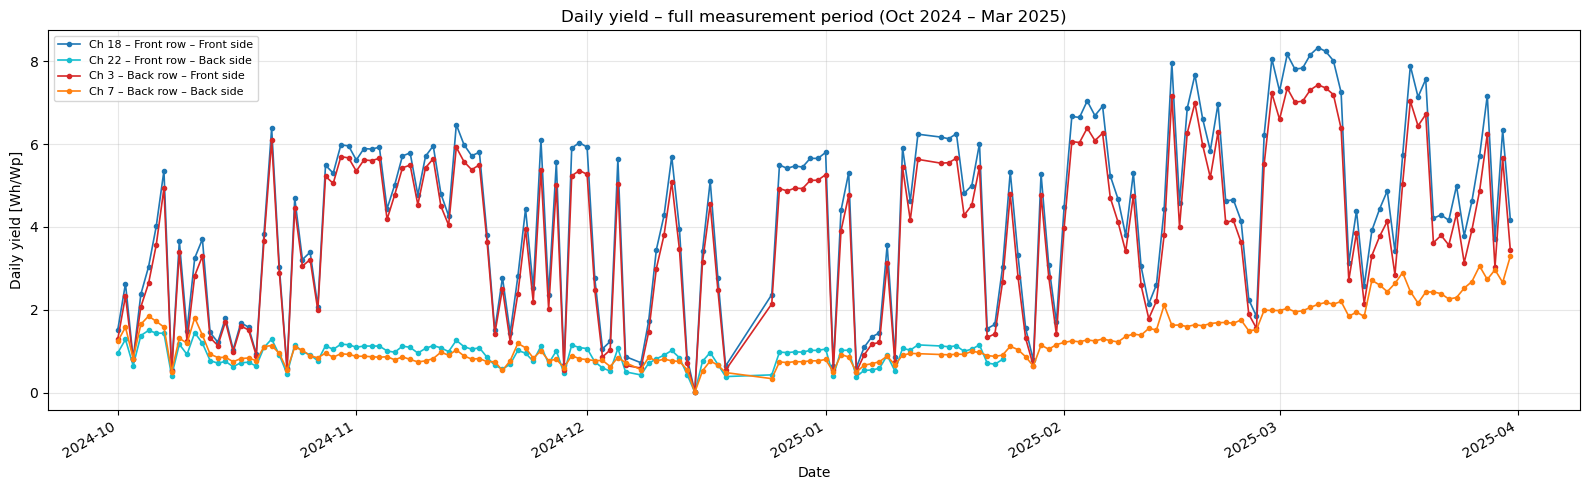

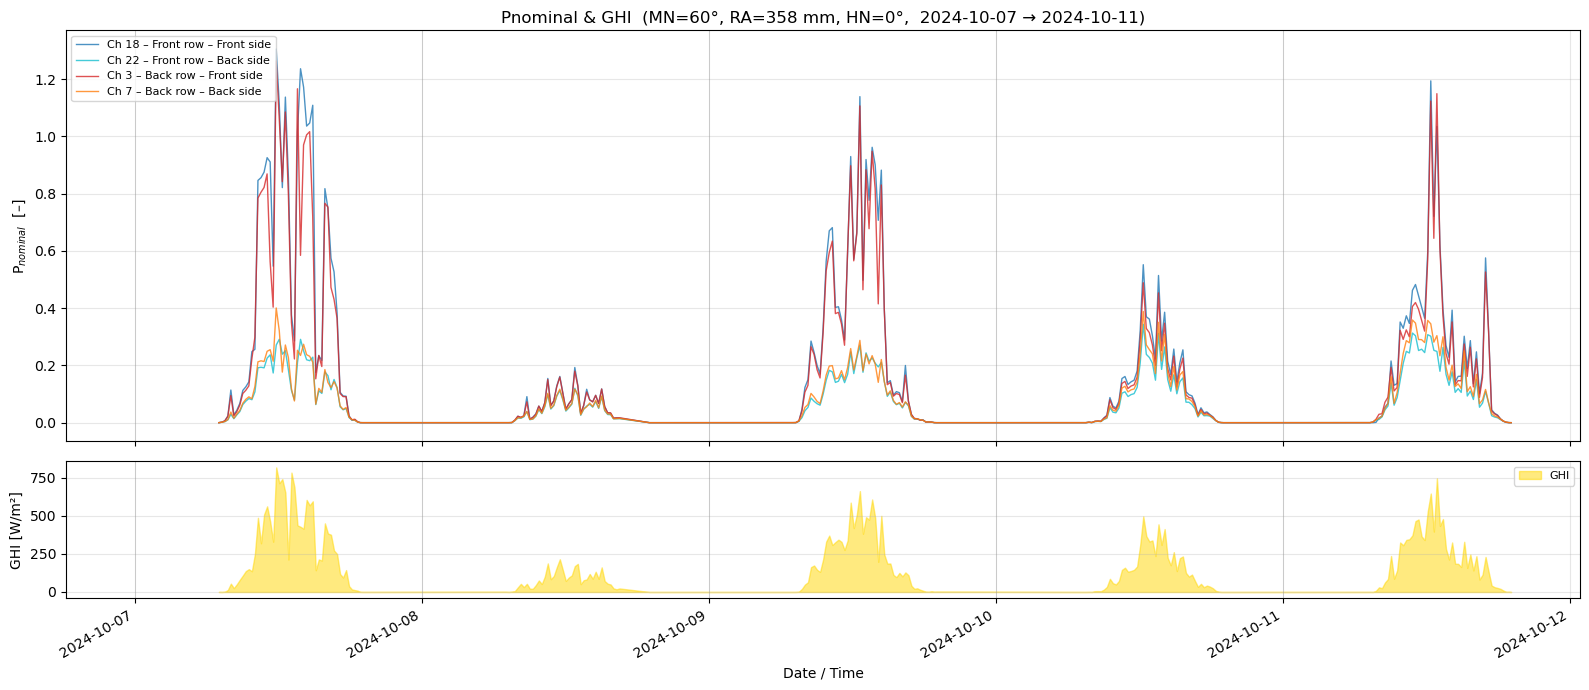

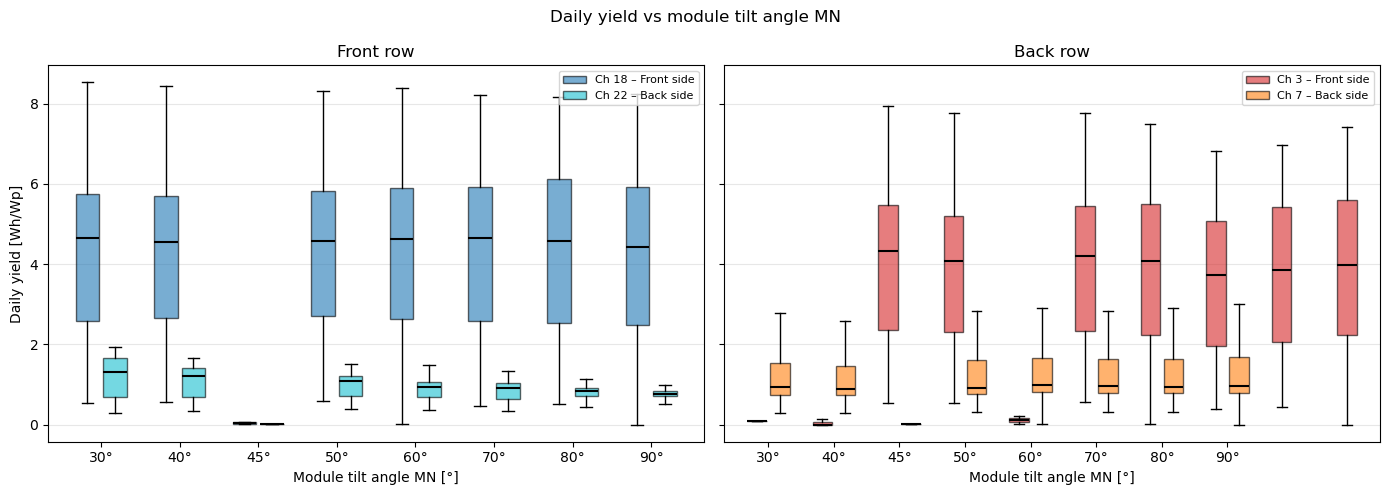

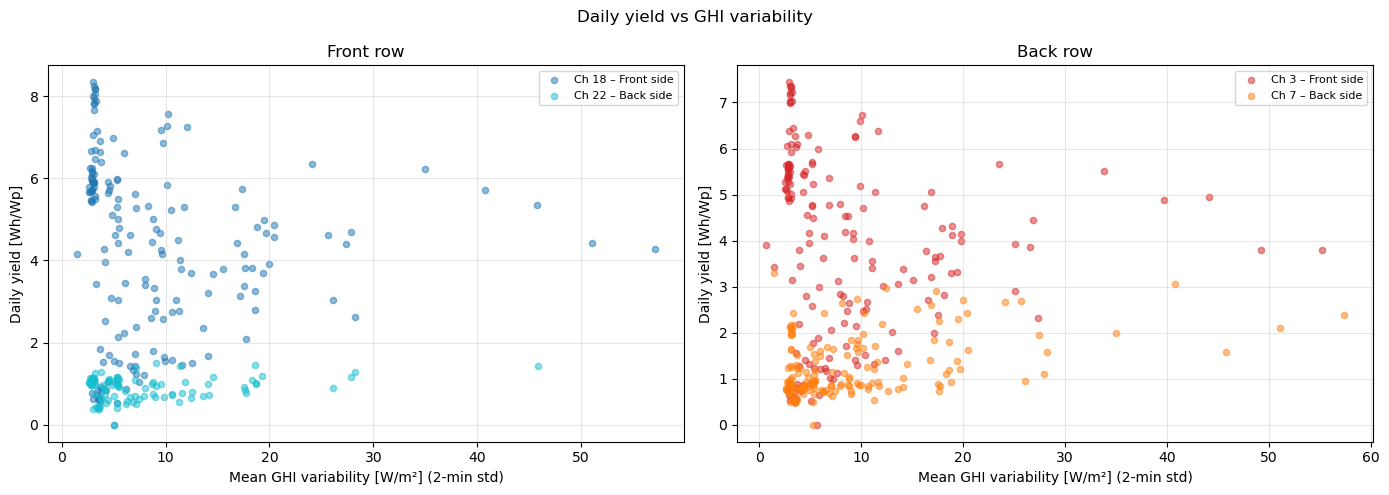

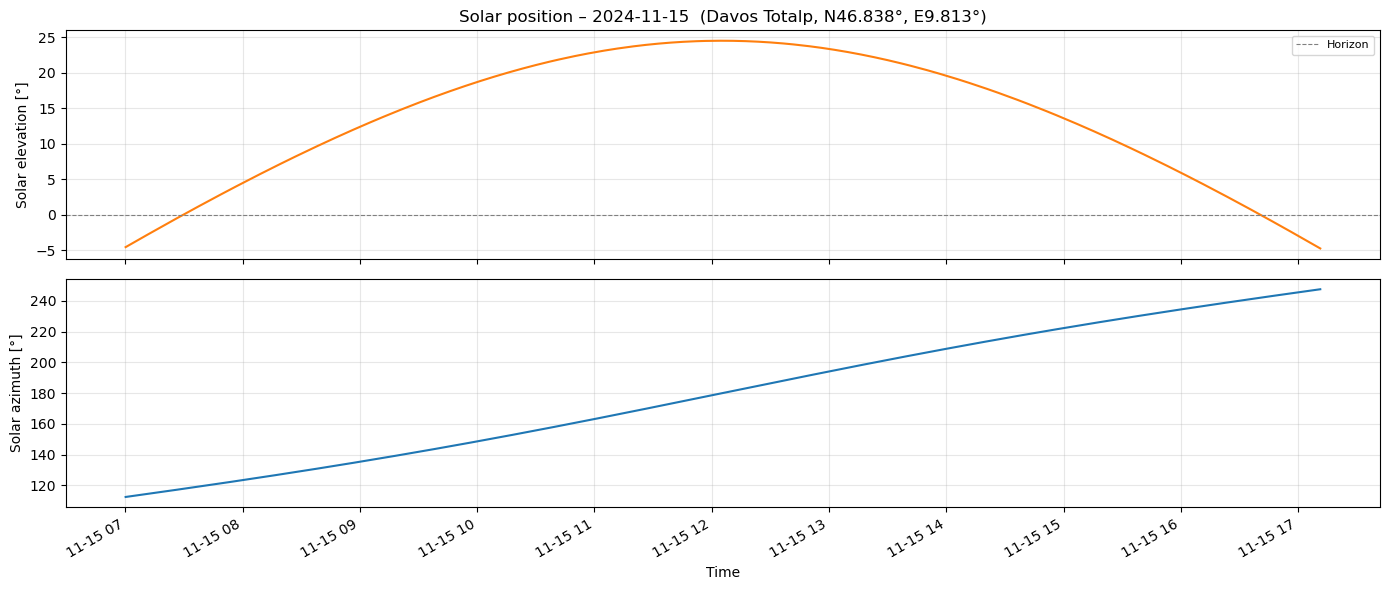

In [12]:
df_rel = combined[combined['channel'].isin(RELEVANT_CHANNELS.keys())].copy()

# Plot 1: Daily yield over the full measurement period
fig, ax = plt.subplots(figsize=(16, 5))
for ch, label in RELEVANT_CHANNELS.items():
    daily = calculate_daily_yield(df_rel, ch)
    if len(daily) > 0:
        ax.plot(pd.to_datetime(daily['date']), daily['yield_Wh_Wp'],
                marker='o', ms=3, lw=1.2, color=COLORS[ch],
                label=f'Ch {ch} – {label}')
ax.set_ylabel('Daily yield [Wh/Wp]')
ax.set_xlabel('Date')
ax.set_title('Daily yield – full measurement period (Oct 2024 – Mar 2025)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Plot 2: Pnominal + GHI over several days
MN_SEL, RA_SEL, HN_SEL = 60, 358, 0
DATE_START, DATE_END    = '2024-10-07', '2024-10-11'

df_plot = filter_combined(df_rel, MN=MN_SEL, RA=RA_SEL, HN=HN_SEL,
                          date_start=DATE_START, date_end=DATE_END,
                          sun_up_only=False)

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
ax_pv, ax_ghi = axes

for ch, label in RELEVANT_CHANNELS.items():
    grp = df_plot[df_plot['channel'] == ch].sort_values('mes_date')
    ax_pv.plot(grp['mes_date'], grp['Pnominal'],
               lw=1.0, alpha=0.8, color=COLORS[ch], label=f'Ch {ch} – {label}')

ax_pv.set_ylabel('P$_{nominal}$  [–]')
ax_pv.set_title(f'Pnominal & GHI  (MN={MN_SEL}°, RA={RA_SEL} mm, HN={HN_SEL}°,  '
                f'{DATE_START} → {DATE_END})')
ax_pv.legend(fontsize=8)
ax_pv.grid(True, alpha=0.3)

ghi_plot = df_plot[df_plot['channel'] == 18].sort_values('mes_date')
ax_ghi.fill_between(ghi_plot['mes_date'], ghi_plot['GHI'],
                    alpha=0.5, color='gold', label='GHI')
ax_ghi.set_ylabel('GHI [W/m²]')
ax_ghi.set_xlabel('Date / Time')
ax_ghi.legend(fontsize=8)
ax_ghi.grid(True, alpha=0.3)

for date in pd.date_range(DATE_START, DATE_END, freq='D', tz=TZ):
    ax_pv.axvline(date,  color='grey', lw=0.5, alpha=0.4)
    ax_ghi.axvline(date, color='grey', lw=0.5, alpha=0.4)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Plot 3: Daily yield vs module tilt angle MN (boxplot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (ch_front, ch_back), row_name in zip(
    axes, [(18, 22), (3, 7)], ['Front row', 'Back row']
):
    for ch, style, label_side in [
        (ch_front, dict(color=COLORS[ch_front]), 'Front side'),
        (ch_back,  dict(color=COLORS[ch_back]),  'Back side'),
    ]:
        mn_yields = {}
        for mn in sorted(df_rel['MN'].unique()):
            daily = calculate_daily_yield(df_rel, ch, MN=mn)
            if len(daily) > 0:
                mn_yields[mn] = daily['yield_Wh_Wp'].values

        mn_labels = sorted(mn_yields.keys())
        data      = [mn_yields[mn] for mn in mn_labels]
        positions = [i + (0 if ch == ch_front else 0.35)
                     for i in range(len(mn_labels))]

        bp = ax.boxplot(data, positions=positions, widths=0.3,
                        patch_artist=True, showfliers=False,
                        medianprops=dict(color='black', lw=1.5))
        for patch in bp['boxes']:
            patch.set_facecolor(style['color'])
            patch.set_alpha(0.6)
        bp['boxes'][0].set_label(f'Ch {ch} – {label_side}')

    ax.set_xticks([i + 0.175 for i in range(len(mn_labels))])
    ax.set_xticklabels([f'{mn}°' for mn in mn_labels])
    ax.set_xlabel('Module tilt angle MN [°]')
    ax.set_title(f'{row_name}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

axes[0].set_ylabel('Daily yield [Wh/Wp]')
fig.suptitle('Daily yield vs module tilt angle MN', fontsize=12)
plt.tight_layout()
plt.show()

# Plot 4: Daily yield vs GHI variability (scatter)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (ch_front, ch_back), row_name in zip(
    axes, [(18, 22), (3, 7)], ['Front row', 'Back row']
):
    for ch, label_side in [(ch_front, 'Front side'), (ch_back, 'Back side')]:
        daily = calculate_daily_yield(df_rel, ch)
        if len(daily) == 0:
            continue
        ghi_daily = (
            df_rel[df_rel['channel'] == ch]
            .assign(date=lambda x: x['mes_date'].dt.date)
            .groupby('date')['GHI_std_2min']
            .mean()
            .reset_index()
        )
        merged = daily.merge(ghi_daily, on='date', how='inner')
        ax.scatter(merged['GHI_std_2min'], merged['yield_Wh_Wp'],
                   alpha=0.5, s=20, color=COLORS[ch],
                   label=f'Ch {ch} – {label_side}')

    ax.set_xlabel('Mean GHI variability [W/m²] (2-min std)')
    ax.set_ylabel('Daily yield [Wh/Wp]')
    ax.set_title(f'{row_name}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Daily yield vs GHI variability', fontsize=12)
plt.tight_layout()
plt.show()

# Plot 5: Solar position (elevation & azimuth)
EXAMPLE_DATE = '2024-11-15'

sol_day = combined[
    (combined['mes_date'].dt.date == pd.Timestamp(EXAMPLE_DATE).date()) &
    (combined['channel'] == 18)
].sort_values('mes_date')

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ax_el, ax_az = axes

ax_el.plot(sol_day['mes_date'], sol_day['solar_elevation'], color='tab:orange', lw=1.5)
ax_el.axhline(0, color='grey', lw=0.8, linestyle='--', label='Horizon')
ax_el.set_ylabel('Solar elevation [°]')
ax_el.set_title(f'Solar position – {EXAMPLE_DATE}  (Davos Totalp, N{LAT}°, E{LON}°)')
ax_el.legend(fontsize=8)
ax_el.grid(True, alpha=0.3)

ax_az.plot(sol_day['mes_date'], sol_day['solar_azimuth'], color='tab:blue', lw=1.5)
ax_az.set_ylabel('Solar azimuth [°]')
ax_az.set_xlabel('Time')
ax_az.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 12. Bifacial Yield Calculation

The Mini-PVA measures front and back sides **sequentially** (not simultaneously).
Bifacial yield is therefore computed at the **daily integral level**:

$$Y_\text{bif} = Y_\text{front} + 0.9 \times Y_\text{back} \quad \text{[Wh/Wp]}$$

The bifaciality factor of 0.9 is specified in the project assignment.
Combining at the integral level (not instantaneous power) is physically correct
because the timing offset between front and back measurements is only ~1 s.

In [13]:
BIFACIALITY = 0.9

def calculate_bifacial_yield(df, ch_front, ch_back,
                              MN=None, RA=None, HN=None,
                              date_start=None, date_end=None):
    """
    Calculate daily bifacial yield [Wh/Wp]:
        Y_bif = Y_front + 0.9 × Y_back

    Front and back are integrated separately and combined at the daily level.
    Only days present in both front and back data are included.
    """
    daily_front = calculate_daily_yield(df, ch_front, MN, RA, HN, date_start, date_end)
    daily_back  = calculate_daily_yield(df, ch_back,  MN, RA, HN, date_start, date_end)

    if len(daily_front) == 0 or len(daily_back) == 0:
        return pd.DataFrame(columns=['date', 'yield_Wh_Wp_front',
                                     'yield_Wh_Wp_back', 'yield_bifacial'])

    merged = daily_front.merge(daily_back, on='date', how='inner',
                               suffixes=('_front', '_back'))

    if len(merged) == 0:
        return pd.DataFrame(columns=['date', 'yield_Wh_Wp_front',
                                     'yield_Wh_Wp_back', 'yield_bifacial'])

    merged['yield_bifacial'] = (
        merged['yield_Wh_Wp_front'] + BIFACIALITY * merged['yield_Wh_Wp_back']
    )
    return merged


# Example: bifacial yield for October 2024, Group 1 focus (HN ≥ 20°)
print("── Example: Bifacial yield for October 2024 (HN ≥ 20°) ──────────────────")
for (ch_f, ch_b), row_name in [((18, 22), 'Front row'), ((3, 7), 'Back row')]:
    for hn in [20, 30, 40]:
        for mn in [30, 40, 50, 60, 70, 80, 90]:
            bif = calculate_bifacial_yield(
                combined, ch_f, ch_b, MN=mn, HN=hn,
                date_start='2024-10-01', date_end='2024-10-31'
            )
            if len(bif) > 0:
                print(f"  {row_name} | HN={hn}°, MN={mn}°: "
                      f"{bif['yield_bifacial'].sum():.2f} Wh/Wp")

── Example: Bifacial yield for October 2024 (HN ≥ 20°) ──────────────────
  Front row | HN=20°, MN=40°: 120.77 Wh/Wp
  Front row | HN=20°, MN=70°: 112.75 Wh/Wp
  Front row | HN=30°, MN=30°: 122.38 Wh/Wp
  Front row | HN=30°, MN=60°: 109.94 Wh/Wp
  Back row | HN=20°, MN=40°: 115.09 Wh/Wp
  Back row | HN=20°, MN=70°: 107.71 Wh/Wp
  Back row | HN=30°, MN=30°: 119.44 Wh/Wp
  Back row | HN=30°, MN=60°: 110.53 Wh/Wp


### 13. Performance Map – Group Focus HN ≥ 20°

Bifacial yield as a function of row spacing (RA), module tilt (MN), and ground slope (HN)
over the full measurement period. A minimum of 5 measurement days per configuration
is required for inclusion.

Calculating performance map (this may take a moment)...
Performance map: 24 configurations with sufficient data

⚠  HN=40: 0 configurations with ≥5 days (insufficient measurement coverage)


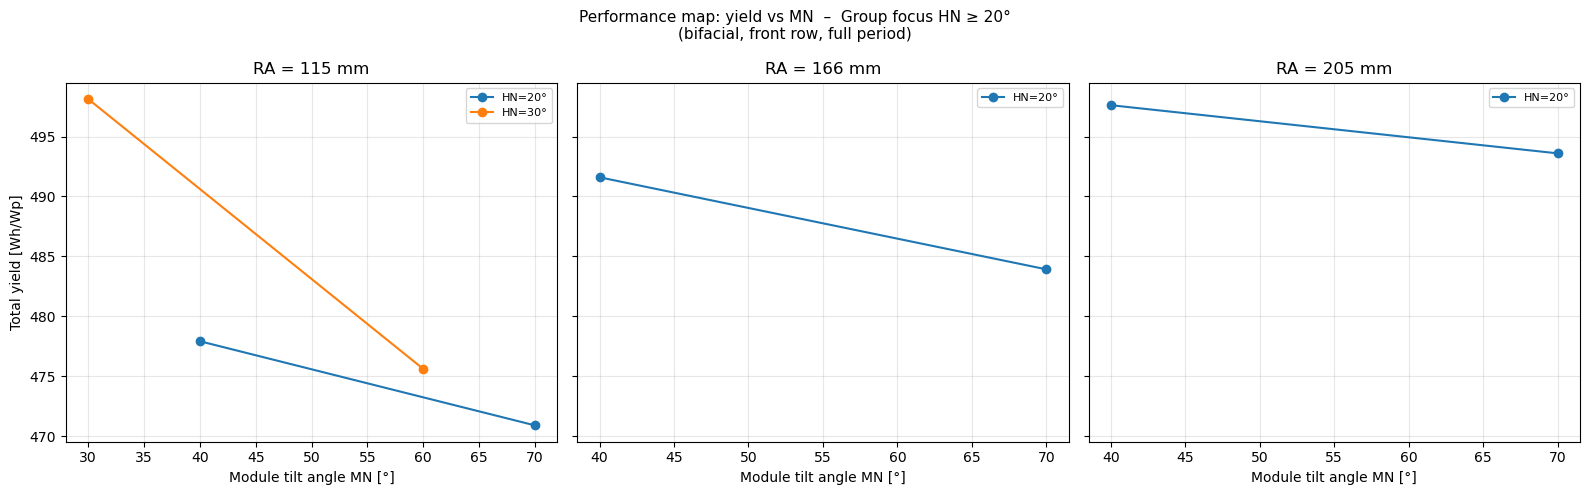

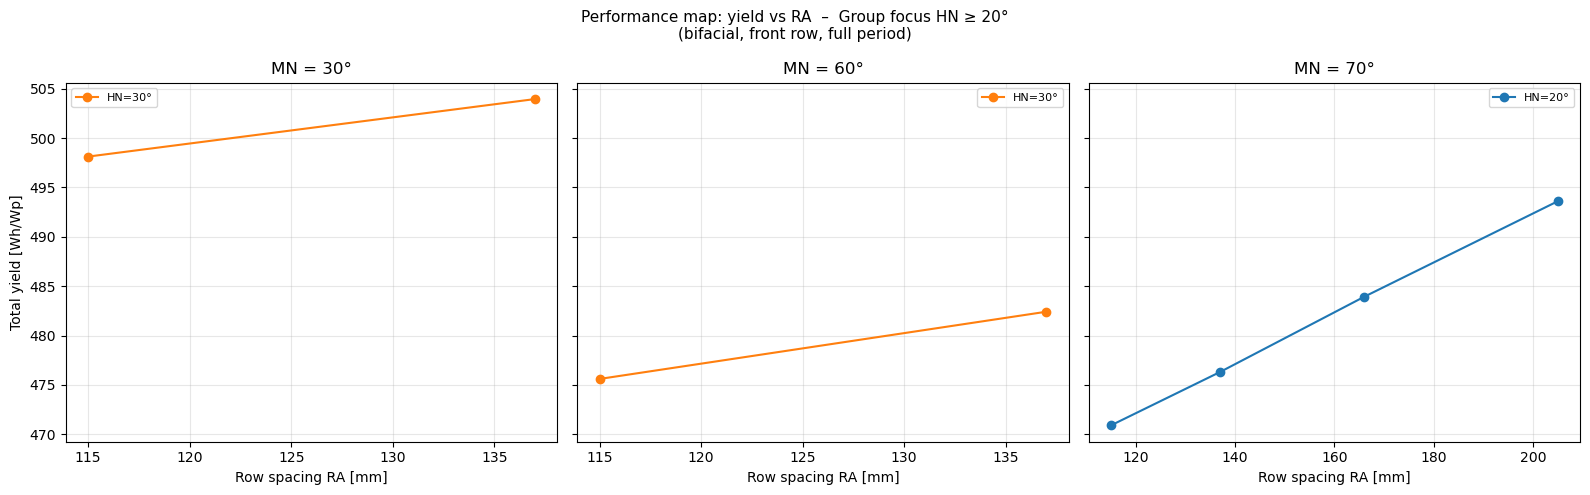


── Available configurations ──────────────────────────────────────────────
HN  MN
20  40    [115, 137, 166, 205]
    70    [115, 137, 166, 205]
30  30              [115, 137]
    60              [115, 137]
HN values with data: [20, 30]


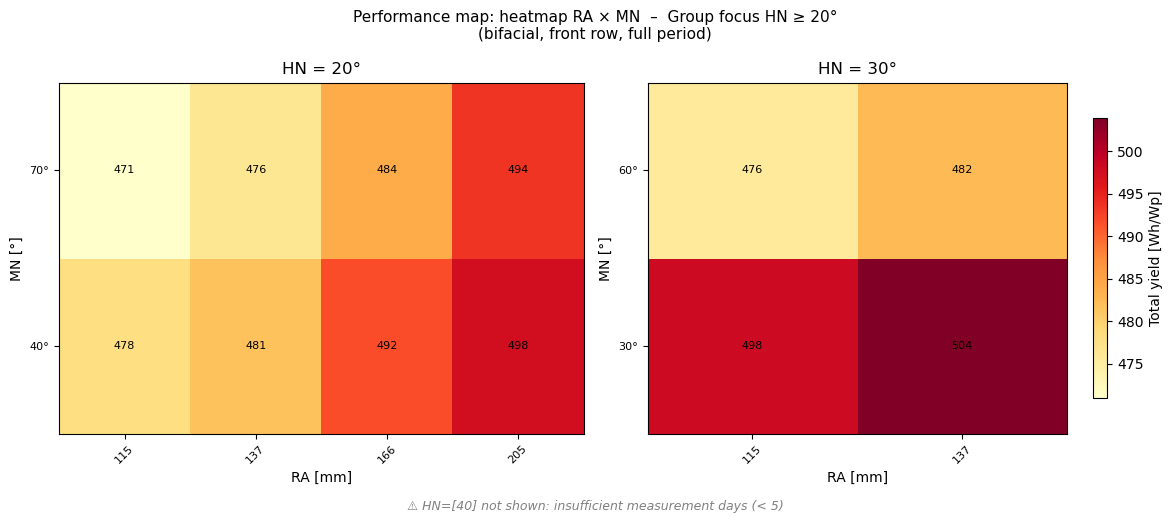


── Best configuration per HN ────────────────────────────────────────────
  HN=20°: MN=40°, RA=205 mm → 497.61 Wh/Wp total, 4.651 Wh/Wp/day (107 days)
  HN=30°: MN=30°, RA=137 mm → 503.95 Wh/Wp total, 4.710 Wh/Wp/day (107 days)


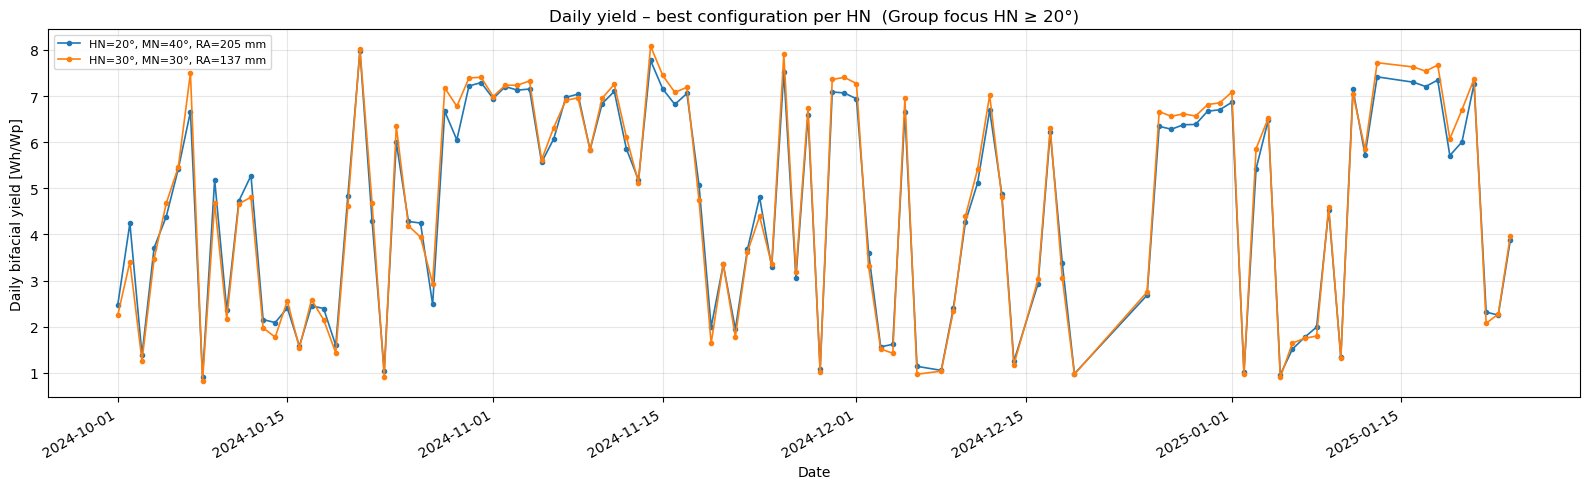


── Performance map summary ───────────────────────────────────────────────
   yield_total                                                                 \
         count     mean      std      min      25%      50%      75%      max   
HN                                                                              
20        16.0  657.411  182.517  470.896  483.312  624.795  833.638  908.742   
30         8.0  674.778  198.948  475.602  494.196  661.567  856.472  901.887   

   yield_per_day                                                   
           count   mean    std    min    25%    50%    75%    max  
HN                                                                 
20          16.0  4.663  0.257  4.347  4.488  4.604  4.819  5.253  
30           8.0  4.774  0.257  4.445  4.619  4.722  4.951  5.213  


In [14]:
HN_FOCUS  = [20, 30, 40]
MN_VALUES = [30, 40, 50, 60, 70, 80, 90]
RA_VALUES = sorted(combined['RA'].dropna().unique())

print("Calculating performance map (this may take a moment)...")

records = []
for hn in HN_FOCUS:
    for mn in MN_VALUES:
        for ra in RA_VALUES:
            for (ch_f, ch_b), row_name in [((18, 22), 'Front row'), ((3, 7), 'Back row')]:
                bif = calculate_bifacial_yield(combined, ch_f, ch_b, MN=mn, RA=ra, HN=hn)
                if len(bif) >= 5:
                    records.append({
                        'HN': hn, 'MN': mn, 'RA': ra,
                        'row':           row_name,
                        'yield_total':   bif['yield_bifacial'].sum(),
                        'yield_per_day': bif['yield_bifacial'].mean(),
                        'n_days':        len(bif),
                    })

perf_map = pd.DataFrame(records)
print(f"Performance map: {len(perf_map)} configurations with sufficient data")

pm_front = perf_map[perf_map['row'] == 'Front row'].copy()

print(f"\n⚠  HN=40: {len(perf_map[perf_map['HN']==40])} configurations with ≥5 days "
      f"(insufficient measurement coverage)")

colors_hn    = {20: 'tab:blue', 30: 'tab:orange', 40: 'tab:red'}
ra_available = sorted(pm_front['RA'].unique())
mn_available = sorted(pm_front['MN'].unique())

# Plot A: yield vs MN for representative RA values
ra_sel = [ra_available[0], ra_available[len(ra_available)//2], ra_available[-1]]

fig, axes = plt.subplots(1, len(ra_sel), figsize=(16, 5), sharey=True)
for ax, ra in zip(axes, ra_sel):
    sub = pm_front[pm_front['RA'] == ra]
    for hn in HN_FOCUS:
        d = sub[sub['HN'] == hn].sort_values('MN')
        if len(d) > 0:
            ax.plot(d['MN'], d['yield_total'],
                    marker='o', lw=1.5, color=colors_hn[hn], label=f'HN={hn}°')
    ax.set_title(f'RA = {ra} mm')
    ax.set_xlabel('Module tilt angle MN [°]')
    ax.grid(True, alpha=0.3)
    if len(sub) > 0:
        ax.legend(fontsize=8)

axes[0].set_ylabel('Total yield [Wh/Wp]')
fig.suptitle('Performance map: yield vs MN  –  Group focus HN ≥ 20°\n'
             '(bifacial, front row, full period)', fontsize=11)
plt.tight_layout()
plt.show()

# Plot B: yield vs RA for representative MN values
mn_sel = [mn_available[0], mn_available[len(mn_available)//2], mn_available[-1]]

fig, axes = plt.subplots(1, len(mn_sel), figsize=(16, 5), sharey=True)
for ax, mn in zip(axes, mn_sel):
    sub = pm_front[pm_front['MN'] == mn]
    for hn in HN_FOCUS:
        d = sub[sub['HN'] == hn].sort_values('RA')
        if len(d) > 0:
            ax.plot(d['RA'], d['yield_total'],
                    marker='o', lw=1.5, color=colors_hn[hn], label=f'HN={hn}°')
    ax.set_title(f'MN = {mn}°')
    ax.set_xlabel('Row spacing RA [mm]')
    ax.grid(True, alpha=0.3)
    if len(sub) > 0:
        ax.legend(fontsize=8)

axes[0].set_ylabel('Total yield [Wh/Wp]')
fig.suptitle('Performance map: yield vs RA  –  Group focus HN ≥ 20°\n'
             '(bifacial, front row, full period)', fontsize=11)
plt.tight_layout()
plt.show()

print("\n── Available configurations ──────────────────────────────────────────────")
print(pm_front.groupby(['HN', 'MN'])['RA'].apply(list).to_string())

# Plot C: heatmap RA × MN per HN
hn_with_data = sorted(pm_front['HN'].unique())
print(f"HN values with data: {hn_with_data}")

fig, axes = plt.subplots(1, len(hn_with_data), figsize=(12, 5))
if len(hn_with_data) == 1:
    axes = [axes]

im = None
for ax, hn in zip(axes, hn_with_data):
    sub   = pm_front[pm_front['HN'] == hn]
    pivot = sub.pivot_table(index='MN', columns='RA', values='yield_total')

    im = ax.imshow(pivot.values, aspect='auto', origin='lower',
                   cmap='YlOrRd',
                   vmin=pm_front['yield_total'].min(),
                   vmax=pm_front['yield_total'].max())

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                        fontsize=8, color='black')

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([str(int(r)) for r in pivot.columns], rotation=45, fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{int(m)}°' for m in pivot.index], fontsize=8)
    ax.set_xlabel('RA [mm]')
    ax.set_ylabel('MN [°]')
    ax.set_title(f'HN = {hn}°')

if im is not None:
    fig.colorbar(im, ax=axes[-1], label='Total yield [Wh/Wp]', shrink=0.8)

missing_hn = [hn for hn in HN_FOCUS if hn not in hn_with_data]
if missing_hn:
    fig.text(0.5, -0.02,
             f'⚠ HN={missing_hn} not shown: insufficient measurement days (< 5)',
             ha='center', fontsize=9, color='grey', style='italic')

fig.suptitle('Performance map: heatmap RA × MN  –  Group focus HN ≥ 20°\n'
             '(bifacial, front row, full period)', fontsize=11)
plt.tight_layout()
plt.show()

# Plot D: daily bifacial yield for best configuration per HN
print("\n── Best configuration per HN ────────────────────────────────────────────")
best_configs = {}
for hn in HN_FOCUS:
    sub = pm_front[pm_front['HN'] == hn]
    if len(sub) == 0:
        continue
    best = sub.loc[sub['yield_total'].idxmax()]
    best_configs[hn] = best
    print(f"  HN={hn}°: MN={int(best['MN'])}°, RA={int(best['RA'])} mm "
          f"→ {best['yield_total']:.2f} Wh/Wp total, "
          f"{best['yield_per_day']:.3f} Wh/Wp/day ({int(best['n_days'])} days)")

fig, ax = plt.subplots(figsize=(16, 5))
for hn, cfg in best_configs.items():
    bif = calculate_bifacial_yield(
        combined, 18, 22,
        MN=int(cfg['MN']), RA=int(cfg['RA']), HN=hn
    )
    if len(bif) > 0:
        ax.plot(pd.to_datetime(bif['date']), bif['yield_bifacial'],
                marker='o', ms=3, lw=1.2, color=colors_hn[hn],
                label=f'HN={hn}°, MN={int(cfg["MN"])}°, RA={int(cfg["RA"])} mm')

ax.set_ylabel('Daily bifacial yield [Wh/Wp]')
ax.set_xlabel('Date')
ax.set_title('Daily yield – best configuration per HN  (Group focus HN ≥ 20°)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print("\n── Performance map summary ───────────────────────────────────────────────")
print(perf_map.groupby('HN')[['yield_total', 'yield_per_day']].describe().round(3))

### 14. In-Plane Irradiance (POA) via pvlib

POA (Plane-of-Array) irradiance is the total irradiance incident on the module surface,
accounting for module tilt and azimuth. It is used as a feature in the regression model.

DHI is not directly measured and is estimated as:  
`DHI = max(GHI − DNI × cos(zenith), 0)`

The site is south-facing (azimuth = 180°) and surface tilt equals MN.

In [15]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')


def calculate_poa_irradiance(mn_deg, hn_deg, env_df, solpos_df_full):
    """
    Calculate daily total POA irradiance [Wh/m²] for a given module tilt (MN).
    Uses pvlib's get_total_irradiance() with Perez transposition model.
    """
    df  = env_df.copy()
    sol = solpos_df_full[['zenith', 'elevation', 'azimuth']].copy()
    sol = sol[sol['elevation'] > 0]

    df = df.merge(sol, left_on='Timestamp', right_index=True, how='inner')
    df = df[df['elevation'] > 0].copy()

    cos_zen   = np.cos(np.radians(df['zenith']))
    df['DHI'] = np.maximum(df['GHI'] - df['DNI'] * cos_zen, 0)

    poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt    = mn_deg,
        surface_azimuth = 180,
        solar_zenith    = df['zenith'],
        solar_azimuth   = df['azimuth'],
        dni             = df['DNI'],
        ghi             = df['GHI'],
        dhi             = df['DHI'],
    )
    df['POA'] = poa['poa_global']
    df['date'] = df['Timestamp'].dt.date
    return df.groupby('date')['POA'].sum() / 3600


# IMPORTANT: assign Timestamp series directly (not .values) to preserve timezone
print("Calculating solar position for environmental timestamps...")
solpos_env       = location.get_solarposition(env_data_full['Timestamp'])
solpos_env.index = env_data_full['Timestamp']

print("Calculating POA irradiance for measured MN values...")
poa_by_mn = {}
for mn in [30, 40, 60, 70]:
    poa_by_mn[mn] = calculate_poa_irradiance(mn, 0, env_data_full, solpos_env)
    print(f"  MN={mn}°: {poa_by_mn[mn].sum():.0f} Wh/m² total period")

Calculating solar position for environmental timestamps...
Calculating POA irradiance for measured MN values...
  MN=30°: 61368 Wh/m² total period
  MN=40°: 65050 Wh/m² total period
  MN=60°: 67799 Wh/m² total period
  MN=70°: 66782 Wh/m² total period


### 15. Regression Model – Aggregated Yields

**Goal:** predict yield for unmeasured configurations (e.g. HN=40, other RA/MN combinations).  
**Training data:** 12 aggregated total yields (one per measured configuration).

> ⚠ Only 12 training points — cross-validation is not meaningful.  
> This model serves as a methodological illustration only.

In [16]:
poa_total_by_mn      = {mn: v.sum() for mn, v in poa_by_mn.items()}
pm_model             = pm_front.copy()
pm_model['POA_total'] = pm_model['MN'].map(poa_total_by_mn)

feature_cols = ['HN', 'MN', 'RA', 'POA_total']
X = pm_model[feature_cols].values
y = pm_model['yield_total'].values

print(f"Training data: {len(X)} configurations")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = GradientBoostingRegressor(
    n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42
)
model.fit(X_scaled, y)

print("\nFeature importance (12 training points):")
for feat, imp in zip(feature_cols, model.feature_importances_):
    print(f"  {feat}: {imp:.3f}")

mn_poa_known = np.array(sorted(poa_total_by_mn.keys()))
poa_known    = np.array([poa_total_by_mn[mn] for mn in mn_poa_known])
RA_ALL       = sorted(combined['RA'].dropna().unique())

pred_records = []
for hn in [20, 30, 40]:
    for mn in [30, 40, 50, 60, 70, 80, 90]:
        poa_mn = float(np.interp(mn, mn_poa_known, poa_known))
        for ra in RA_ALL:
            feat      = scaler.transform([[hn, mn, ra, poa_mn]])
            y_pred    = model.predict(feat)[0]
            measured  = pm_front[
                (pm_front['HN'] == hn) &
                (pm_front['MN'] == mn) &
                (pm_front['RA'] == ra)
            ]
            y_measured = measured['yield_total'].values[0] if len(measured) > 0 else np.nan
            pred_records.append({
                'HN': hn, 'MN': mn, 'RA': ra,
                'POA_total': poa_mn,
                'yield_predicted': y_pred,
                'yield_measured':  y_measured,
                'has_data':        not np.isnan(y_measured),
            })

pred_df = pd.DataFrame(pred_records)
print(f"\nPredictions: {len(pred_df)} configurations total")
print(f"  measured:   {pred_df['has_data'].sum()}")
print(f"  predicted:  {(~pred_df['has_data']).sum()}")

Training data: 12 configurations

Feature importance (12 training points):
  HN: 0.016
  MN: 0.306
  RA: 0.487
  POA_total: 0.192

Predictions: 210 configurations total
  measured:   12
  predicted:  198


### 15b. Improved Model – Daily Yields as Training Data

Instead of 12 aggregated totals, ~1260 daily yield values are used as training data.
This enables meaningful 5-fold cross-validation (R² = 0.94).

> ⚠ **Limitation:** POA_day accounts for 98% of feature importance.  
> The model has learned the **weather effect** (more sun = more yield), not the  
> **configuration effect** (RA, MN, HN differences). Day-to-day weather variation  
> dominates over configuration differences in this dataset.  
> The model is suitable for interpolation within measured configurations,  
> but **not** for robust extrapolation to unmeasured ones.

In [17]:
from sklearn.model_selection import KFold

daily_records = []
for (ch_f, ch_b), row_name in [((18, 22), 'Front row'), ((3, 7), 'Back row')]:
    for hn, mn, ra in [
        (20, 40, 115), (20, 40, 137), (20, 40, 166), (20, 40, 205),
        (20, 70, 115), (20, 70, 137), (20, 70, 166), (20, 70, 205),
        (30, 30, 115), (30, 30, 137),
        (30, 60, 115), (30, 60, 137),
    ]:
        bif = calculate_bifacial_yield(combined, ch_f, ch_b, MN=mn, RA=ra, HN=hn)
        if len(bif) == 0:
            continue

        poa_mn_daily = poa_by_mn.get(mn)
        if poa_mn_daily is None:
            continue

        for _, row in bif.iterrows():
            date    = row['date']
            poa_day = poa_mn_daily.get(date, np.nan)
            if np.isnan(poa_day) or poa_day <= 0:
                continue
            daily_records.append({
                'HN': hn, 'MN': mn, 'RA': ra,
                'row':     row_name,
                'date':    date,
                'POA_day': poa_day,
                'yield_day': row['yield_bifacial'],
            })

daily_df       = pd.DataFrame(daily_records)
daily_df_front = daily_df[daily_df['row'] == 'Front row'].copy()

print(f"Daily training data: {len(daily_df_front)} data points "
      f"(vs. 12 aggregated values in Section 15)")

feature_cols_daily = ['HN', 'MN', 'RA', 'POA_day']
X_daily = daily_df_front[feature_cols_daily].values
y_daily = daily_df_front['yield_day'].values

scaler_daily   = StandardScaler()
X_daily_scaled = scaler_daily.fit_transform(X_daily)

model_daily = GradientBoostingRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42
)
model_daily.fit(X_daily_scaled, y_daily)

cv_scores_daily = cross_val_score(
    model_daily, X_daily_scaled, y_daily,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2'
)
print(f"\nCross-validation R² (5-fold): "
      f"{cv_scores_daily.mean():.3f} ± {cv_scores_daily.std():.3f}")

print("\nFeature importance (daily data):")
for feat, imp in zip(feature_cols_daily, model_daily.feature_importances_):
    print(f"  {feat}: {imp:.3f}")

print("\n⚠ POA_day dominates with 98% feature importance.")
print("  Model captures weather effect, not configuration effect.")
print("  Suitable for interpolation within measured configurations only.")

Daily training data: 1260 data points (vs. 12 aggregated values in Section 15)

Cross-validation R² (5-fold): 0.942 ± 0.012

Feature importance (daily data):
  HN: 0.001
  MN: 0.016
  RA: 0.001
  POA_day: 0.982

⚠ POA_day dominates with 98% feature importance.
  Model captures weather effect, not configuration effect.
  Suitable for interpolation within measured configurations only.


---

## Results & Interpretation – Group Focus HN ≥ 20°

**1. Optimal module tilt at steep ground slopes**  
At HN=20°, MN=40° is optimal; at HN=30°, MN=30° is optimal. This is physically consistent:
the ground slope itself already tilts the array toward the sun — a high additional module
tilt would overcorrect and reduce yield.

**2. Row spacing (RA)**  
Larger row spacing consistently increases yield due to reduced inter-row shading.
The effect is strongest at small RA values (115→205 mm: ~+4%) and flattens at larger spacings.

**3. Data coverage**  
For HN ≥ 20°, only a limited number of configurations were measured:
- HN=20°: MN=40° and MN=70°, RA=115–205 mm
- HN=30°: MN=30° and MN=60°, RA=115–137 mm
- HN=40°: insufficient measurement days (< 5) for statistical analysis

**4. Back-side contribution (bifaciality)**  
The back side contributes approximately 25–35% of total bifacial yield —
amplified by the high snow albedo at this alpine site.

**5. Regression model**  
The daily-yield model (R²=0.94) shows that the weather effect (POA_day = 98% feature
importance) dominates configuration differences. Robust extrapolation to unmeasured
configurations would require a broader set of measured configurations.